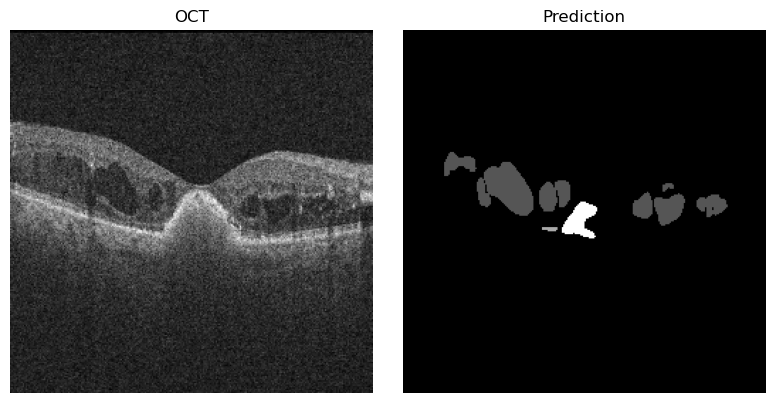

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from losses import Losses

# Load model
model = tf.keras.models.load_model(
    "Spectralis_Cirrus_ori/model_2_epoch30.hdf5",
    custom_objects={
        "training_loss": Losses().training_loss,
        "dice":          Losses().dice
    }
)
loss_funcs = Losses()

# Image loader
def load_oct_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)       
    img = tf.image.resize(img, [256, 256])            
    return tf.cast(img, tf.float32) / 255.0          
  
# Prediction helper
def predict_mask(model, img_tensor):
    out    = model.predict(img_tensor[None], verbose=0)[0]  # [256,256,32]
    conn32 = out[..., :32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]
        bv = loss_funcs.bv_test_new(tf.expand_dims(cm,0)).numpy()  
        prob_maps.append(bv)
    stack = np.stack(prob_maps, axis=-1)  # [256,256,4]
    return np.argmax(stack, axis=-1)      

# Run on example slice
image_path = "dataset/Cirrus/100264586-2023-03-20-145553-OD/" \
             "Cube-1.2.276.0.75.2.2.45.215507188813914." \
             "20230320145553519.7480707390_064.png"

img  = load_oct_image(image_path).numpy()  # [256,256,1]
pred = predict_mask(model, img)

# Plot raw vs. prediction
cmap = ListedColormap(['black','red','green','blue'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
ax1.imshow(img[...,0], cmap='gray')
ax1.set_title("OCT")
ax1.axis('off')
ax2.imshow(pred, cmap='gray', vmin=0, vmax=3)
ax2.set_title("Prediction")
ax2.axis('off')
plt.tight_layout()
plt.show()

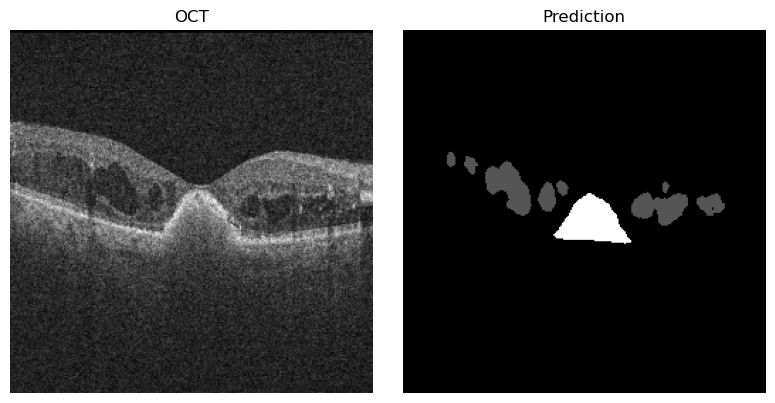

In [ ]:
# load model
model = tf.keras.models.load_model(
    "Spectralis_Cirrus_Topcon/final_model.hdf5",
    custom_objects={
        "training_loss": Losses().training_loss,
        "dice":          Losses().dice
    }
)
loss_funcs = Losses()

# Image loader
def load_oct_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)        
    img = tf.image.resize(img, [256, 256])         
    return tf.cast(img, tf.float32) / 255.0          

# Prediction helper
def predict_mask(model, img_tensor):
    # img_tensor: [256,256,1] float32
    out    = model.predict(img_tensor[None], verbose=0)[0]  # [256,256,32]
    conn32 = out[..., :32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]
        bv = loss_funcs.bv_test_new(tf.expand_dims(cm,0)).numpy()  
        prob_maps.append(bv)
    stack = np.stack(prob_maps, axis=-1)  # [256,256,4]
    return np.argmax(stack, axis=-1)      

# Run on example slice
image_path = "dataset/Cirrus/100264586-2023-03-20-145553-OD/" \
             "Cube-1.2.276.0.75.2.2.45.215507188813914." \
             "20230320145553519.7480707390_064.png"

img  = load_oct_image(image_path).numpy()  # (256,256,1)
pred = predict_mask(model, img)

# Plot raw vs. prediction
cmap = ListedColormap(['black','red','green','blue'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
ax1.imshow(img[...,0], cmap='gray')
ax1.set_title("OCT")
ax1.axis('off')
ax2.imshow(pred, cmap='gray', vmin=0, vmax=3)
ax2.set_title("Prediction")
ax2.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import glob
from tqdm import tqdm
from PIL import Image

# Load model
model = tf.keras.models.load_model(
    "Spectralis_Cirrus_Topcon/final_model.hdf5",
    custom_objects={
        "training_loss": Losses().training_loss,
        "dice":          Losses().dice
    }
)
loss_funcs = Losses()


DATASET_ROOT = "dataset/Cirrus"

for in_name in sorted(os.listdir(DATASET_ROOT)):
    if in_name.endswith('-pred'):
        continue
        
    in_dir = os.path.join(DATASET_ROOT, in_name)
    if not os.path.isdir(in_dir):
        continue

    # output folder name with "-pred" suffix
    if "-" in in_name:
        base     = in_name.rsplit("-", 1)[0]
        out_name = base + "-pred"
    else:
        out_name = in_name + "-pred"

    out_dir = os.path.join(DATASET_ROOT, out_name)
    os.makedirs(out_dir, exist_ok=True)

    # Only files starting with "Cube"
    all_pngs = sorted(glob.glob(os.path.join(in_dir, "*.png")))
    cube_pngs = [p for p in all_pngs 
                 if os.path.basename(p).startswith("Cube")]

    for img_path in tqdm(cube_pngs, desc=f"Predicting {in_name}"):
        img = load_oct_image(img_path).numpy()   # (256,256,1)
        mask = predict_mask(model, img)          # (256,256)

        save_path = os.path.join(out_dir, os.path.basename(img_path))
        im = Image.fromarray(mask.astype(np.uint8), mode='L')
        im.save(save_path)

print("Only Cube images have been processed and saved.") 

Predicting 100264586-2024-06-12-105400-OD: 100%|██████████| 256/256 [00:37<00:00,  6.85it/s]

✅ Done! Only ‘Cube*’ images have been processed and saved.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd

# Configuration
DATASET_ROOT = "dataset/Cirrus"
classes = ['Background', 'IRF', 'SRF', 'PED']

# per-slice class fractions
def slice_fractions(mask, n_classes=4):
    H, W = mask.shape
    return np.array([(mask == c).sum() / (H*W) for c in range(n_classes)])

# scan -pred folders and group by eye id
records = []
for folder_name in sorted(os.listdir(DATASET_ROOT)):
    if not folder_name.endswith('-pred'):
        continue

    folder_path = os.path.join(DATASET_ROOT, folder_name)
    png_files   = sorted(glob.glob(os.path.join(folder_path, '*.png')))
    if not png_files:
        continue

    patient_id = folder_name.replace('-pred', '')
    eye_sums = {}       # accumulate per-eye sums
    for p in png_files:
        basename = os.path.basename(p)[:-4]  # drop .png
        eye_key  = basename.split('_')[0]   # text before first "_"

        mask = np.array(Image.open(p))
        if mask.ndim == 3:
            mask = mask[..., 0]

        fracs = slice_fractions(mask, n_classes=len(classes))
        eye_sums.setdefault(eye_key, np.zeros(len(classes), float))
        eye_sums[eye_key] += fracs

    # record each eye separately
    for eye_key, sum_frac in eye_sums.items():
        rec = {'patient': patient_id, 'eye_id': eye_key}
        for i, cls in enumerate(classes):
            rec[f'{cls}_sum_of_fraction'] = sum_frac[i]
        records.append(rec)

df = pd.DataFrame(records).set_index(['patient','eye_id'])
df['total_sum_of_fraction'] = df.sum(axis=1)
display(df)

Background_sum_of_fraction  \
patient                     eye_id                                                                           
100264586-2023-03-20-145553 Cube-1.2.276.0.75.2.2.45.215507188813914.202303...                  125.507721   
                            Cube-1.2.276.0.75.2.2.45.215507188813914.202303...                  126.715439   
100264586-2024-06-12-105400 Cube-1.2.276.0.75.2.2.45.215507186204154.202406...                  127.307007   
                            Cube-1.2.276.0.75.2.2.45.215507186204154.202406...                  127.907669   

                                                                                IRF_sum_of_fraction  \
patient                     eye_id                                                                    
100264586-2023-03-20-145553 Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             2.226868   
                            Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             1.280319   
100264586-2024-06-12-105400 Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.446182   
                            Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.092163   

                                                                                SRF_sum_of_fraction  \
patient                     eye_id                                                                    
100264586-2023-03-20-145553 Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             0.007217   
                            Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             0.004242   
100264586-2024-06-12-105400 Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.197510   
                            Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.000031   

                                                                                PED_sum_of_fraction  \
patient                     eye_id                                                                    
100264586-2023-03-20-145553 Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             0.258194   
                            Cube-1.2.276.0.75.2.2.45.215507188813914.202303...             0.000000   
100264586-2024-06-12-105400 Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.049301   
                            Cube-1.2.276.0.75.2.2.45.215507186204154.202406...             0.000137   

                                                                                total_sum_of_fraction  
patient                     eye_id                                                                     
100264586-2023-03-20-145553 Cube-1.2.276.0.75.2.2.45.215507188813914.202303...                  128.0  
                            Cube-1.2.276.0.75.2.2.45.215507188813914.202303...                  128.0  
100264586-2024-06-12-105400 Cube-1.2.276.0.75.2.2.45.215507186204154.202406...                  128.0  
                            Cube-1.2.276.0.75.2.2.45.215507186204154.202406...                  128.0